<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


#### Note: All tasks were completed together with inputs and effort of both the members

## Task 1: Implement Logistic Regression

The **sigmoid function** is defined as:

$$
\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}
$$

It is commonly used in logistic regression and neural networks to map any real-valued input to a value between 0 and 1. This makes it suitable for **binary classification problems**, where the output represents a probability.



The **log loss function** (also known as cross-entropy loss) is defined as:

$$
J(w,b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ 
y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) 
\right]
$$

Where:

- $J$ is the cost (log loss)
- $N$ is the number of samples
- $y^{(i)}$ is the true label of the $i$-th sample
- $\hat{y}^{(i)}$ is the predicted probability of the $i$-th sample

This function calculates the **average difference between the true labels and the predicted probabilities**.  
If the predicted probability approaches the correct label, the loss approaches 0.  
If the prediction is incorrect with high confidence, the loss increases significantly and tends toward infinity.



To minimize the cost function, we use the **Gradient Descent algorithm**, which iteratively updates the weights and bias parameters to find their optimal values.

In this implementation, we use **Batch Gradient Descent**, meaning the gradients are computed using the entire dataset in each iteration.


### Algorithm Steps

1. Initialize weights and bias.
2. For each iteration:
   - Compute predicted values using the current weights and bias.
   - Compute the gradients of the cost function with respect to weights and bias.
   - Update the weights and bias using the learning rate.

Weight update rule:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

Bias update rule:

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Where:

- $w$ is the weight vector
- $b$ is the bias term
- $\alpha$ is the learning rate
- $\frac{\partial J}{\partial w}$ is the partial derivative of the cost function with respect to $w$
- $\frac{\partial J}{\partial b}$ is the partial derivative of the cost function with respect to $b$

This iterative process continues until the cost function converges to a minimum value, resulting in optimized parameters for the classification task.


In [1]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Display plots inline
%matplotlib inline

In [3]:
# Sigmoid Function (Activation Function)

def sigmoid(z):
    """
    Implementation of activation function
    Inputs:
    z (linear input)
    Outputs: 
    Binary classification returns probability value between 0 & 1
    """
    return (1 / (1 + (np.exp(-z))))

In [4]:
# Loss function
def compute_loss_lr(y, y_hat):
    """
    Implementation of cross-entropy loss function

    Inputs:
    y = True Label (0 or 1)
    y_hat = Predicted probability (between 0 and 1)

    Output:
    Loss for the classification
    """
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [5]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteria

    Outputs:
    w = learned weights
    b = learned bias
    loss = loss calculated at per iteration
    epoch_loss = loss of a single epoch
    """

    # Initialising parameters
    np.random.seed(42)                        # To ensure same results everytime
    stopping = False                          # To exit the while loop once convergence is met
    J_running = 0                             # Represents cumulative loss of an epoch 
    epoch_number = 0                          # To keep a counter of epochs
    J_running_prev = 0                        # Represents previous epoch loss for convergence comparsion
    prev_avg_loss = float("inf")
    iteration = 0                             # To keep a counter of iterations     
    N,m = X.shape                             # N = no: of samples, m = no:of features
    w = np.random.normal(0, 0.01, size=(m,1)) # Small range of w & b choosen to avoid missing minima
    b = 0.01                                 


    # Implementing SGD
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss_lr(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage: partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [6]:
def predict_lr(X, w, b, threshold):
    """
    Implementation of prediction function

    Inputs:
    X = input features (Testing/validation dataset)
    w = weights (calculated at training stage)
    b = bias (also calculated at traing stage)
    threshold = decision threshold to classify 
    
    Outputs:
    Returns predicted class label based on threshold
    """
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int).reshape(-1)



In [7]:
def evaluate(y, y_pred):
    """
    Evaluates the performance of the logistic regression model using accuracy, precision, recall, and F1-score.

    Inputs:
    y: True binary labels (0 or 1).
    y_pred: Predicted binary class labels (0 or 1).

    Outputs: 
        - accuracy: The accuracy of the model.
        - precision: The precision of the model.
        - recall: The recall of the model.
        - f1_score: The F1-score of the model.
    """
    TP = np.sum((y == 1) & (y_pred == 1))
    TN = np.sum((y == 0) & (y_pred == 0))
    FP = np.sum((y == 0) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1_score

### Learnings of Task 1:
Implemented a Logistic Regression model from scratch using Stochastic Gradient Descent. Learned how forward propagation, sigmoid activation, and cross-entropy loss work together, and how weights and bias are updated iteratively until convergence. Evaluated model performance using accuracy, precision, recall, and F1-score. This exercise enhanced our  understanding of the mathematical intuition behind logistic regression, gradient descent, and binary classification metrics.

## Task 2: Testing on Datasets

In [8]:
def split_data(X, y, random_state = 42):
    '''
    This function splits the entire dataset into 3 sections: train, test, validation
    train_test_split function has the ability to split the dataset into 2 sections initially (train & temp). 
    The temp data is then split again in 2 sections - test & validation.

    Inputs: 
    X, y
    Outputs: 
    X_train, Y_train, X_val, Y_val, X_test, Y_test
    '''
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp)

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [10]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
#df1 = pd.read_csv(r"/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv")
df1= pd.read_csv(r"C:\Users\anush\Downloads\blobs600 (1).csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [11]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


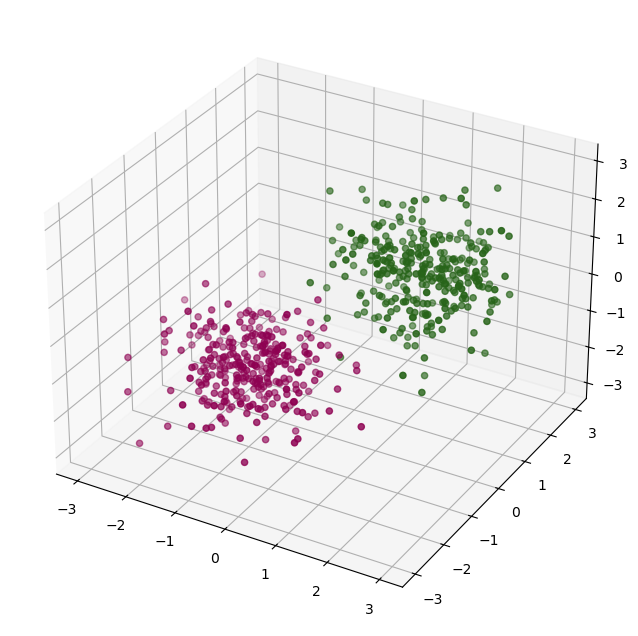

In [12]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

In [13]:
#Splitting the training data & implementing logistic regression function on Dataset 1

X_train1, Y_train1, X_val1, Y_val1, X_test1, Y_test1 = split_data(X1, y1)
w1, b1, loss1, epoch_loss1 = train_logistic_regression(X_train1, Y_train1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(w1, b1, epoch_loss1)

Converged after 5 epochs (2100 iterations)
[[1.4913422 ]
 [1.28627418]
 [1.32349131]] [[-0.00392804]] [0.22564382348108486, 0.08648357526916561, 0.05680247064224819, 0.04308129438218171, 0.042499466083714736]


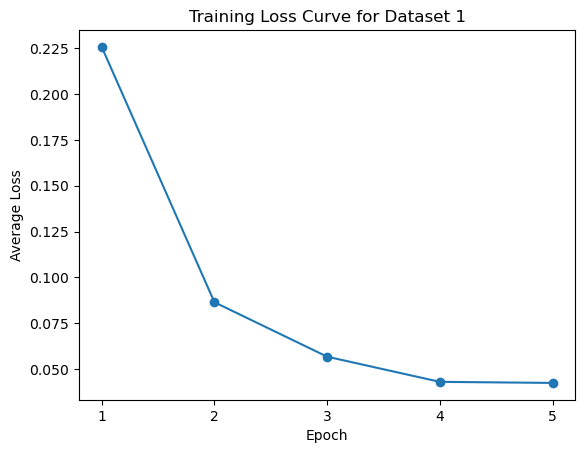

In [14]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 1

plt.plot(range(1, len(epoch_loss1)+1), epoch_loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss1)+1))
plt.show()

In [19]:
# Validate and test performance
y1_val_pred = predict_lr(X_val1, w1, b1, threshold = 0.5)
val_accuracy1, val_precision1, val_recall1, val_f1_1 = evaluate(Y_val1, y1_val_pred)
print(f"Validate Accuracy for dataset1: {val_accuracy1*100:.2f}%")
print(f"Validate Precision for dataset1: {val_precision1*100:.2f}%")
print(f"Validate Recall for dataset1: {val_recall1*100:.2f}%")
print(f"Validate F1-score for dataset1: {val_f1_1*100:.2f}%")

    
y1_test_pred = predict_lr(X_test1, w1, b1, threshold = 0.5)
test_accuracy1, test_precision1, test_recall1, test_f1_1 = evaluate(Y_test1, y1_test_pred)
print(f"Test Accuracy for dataset1: {test_accuracy1*100:.2f}%")
print(f"Test Precision for dataset1: {test_precision1*100:.2f}%")
print(f"Test Recall for dataset1: {test_recall1*100:.2f}%")
print(f"Test F1-score for dataset1: {test_f1_1*100:.2f}%")



Validate Accuracy for dataset1: 98.89%
Validate Precision for dataset1: 97.83%
Validate Recall for dataset1: 100.00%
Validate F1-score for dataset1: 98.90%
Test Accuracy for dataset1: 100.00%
Test Precision for dataset1: 100.00%
Test Recall for dataset1: 100.00%
Test F1-score for dataset1: 100.00%


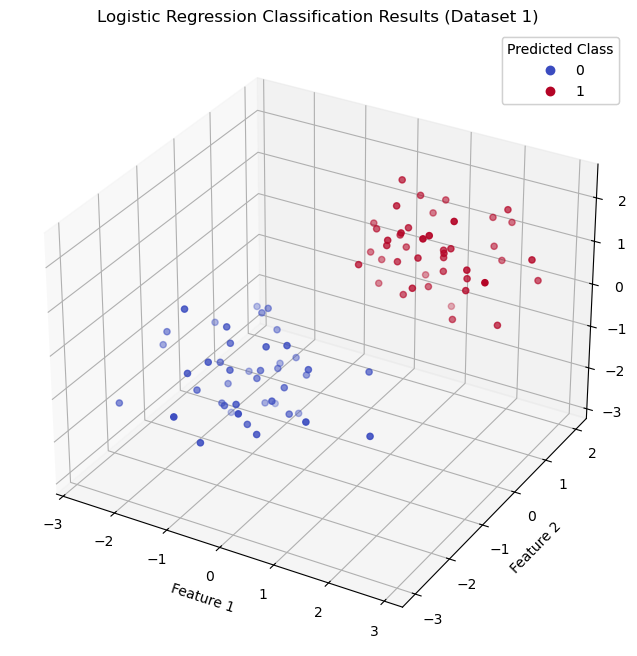

In [20]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(X_test1[:,0], X_test1[:,1], X_test1[:,2],
                     c=y1_test_pred.flatten(),
                     cmap="coolwarm")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("Logistic Regression Classification Results (Dataset 1)")

legend1 = ax.legend(*scatter.legend_elements(), title="Predicted Class")
ax.add_artist(legend1)

plt.show()

In [21]:
# Loading Dataset 2
# Use pandas to read the CSV file as a dataframe
#df2 = pd.read_csv(r"/Users/aakankshadeshpande/Documents/Assignments_Sem2/circles500.csv")
df2 = pd.read_csv(r"C:\Users\anush\Downloads\circles500 (1).csv")
# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [22]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


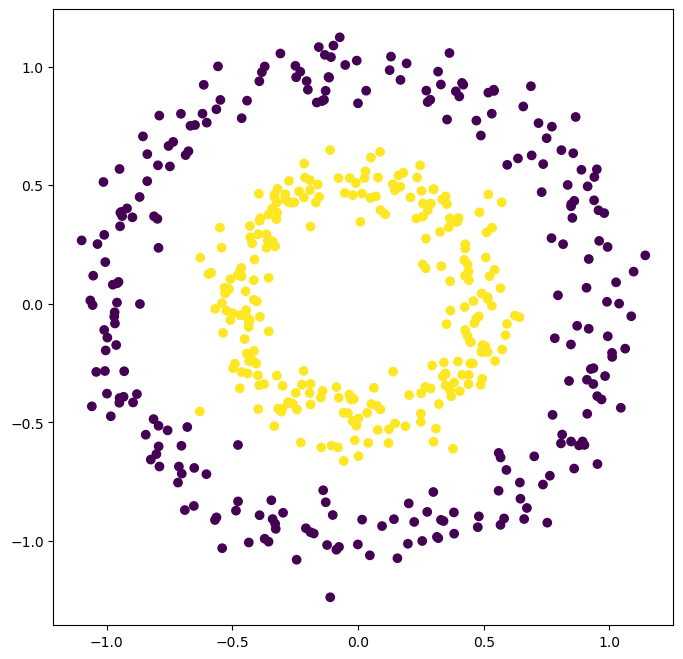

In [23]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

In [77]:
#Splitting the training data & implementing logistic regression function on Dataset 2

X_train2, Y_train2, X_val2, Y_val2, X_test2, Y_test2 = split_data(X2, y2)
w2, b2, loss2, epoch_loss2 = train_logistic_regression(X_train2, Y_train2, alpha=0.001, max_iteration=30000, threshold=1e-5)
print(w2, b2, epoch_loss2)

Converged after 15 epochs (5250 iterations)
[[ 0.02055341]
 [-0.05959059]] [[0.01778555]] [0.6932269301188687, 0.6936125601887095, 0.6927186598581602, 0.693305277507021, 0.6934448791056038, 0.6930822026027503, 0.6931215234014739, 0.6929771197762946, 0.6927576126151938, 0.6924024858958246, 0.6932207165663541, 0.6928253560740266, 0.6927619770863616, 0.6919837675554099, 0.6919751510646842]


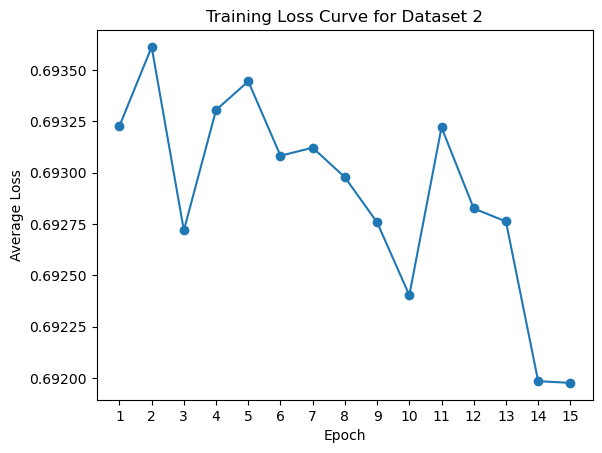

In [78]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 2
plt.plot(range(1, len(epoch_loss2)+1), epoch_loss2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 2")
plt.xticks(range(1, len(epoch_loss2)+1))
plt.show()

In [79]:
# Validate and test performance
y2_val_pred = predict_lr(X_val2, w2, b2, threshold = 0.5)
val_accuracy2, val_precision2, val_recall2, val_f1_2 = evaluate(Y_val2, y2_val_pred)
print(f"Validate Accuracy for dataset2: {val_accuracy2*100:.2f}%")
print(f"Validate Precision for dataset2: {val_precision2*100:.2f}%")
print(f"Validate Recall for dataset2: {val_recall2*100:.2f}%")
print(f"Validate F1-score for dataset2: {val_f1_2*100:.2f}%")
print("\n")
    
y2_test_pred = predict_lr(X_test2, w2, b2, threshold = 0.5)
test_accuracy2, test_precision2, test_recall2, test_f1_2 = evaluate(Y_test2, y2_test_pred)
print(f"Test Accuracy for dataset2: {test_accuracy2*100:.2f}%")
print(f"Test Precision for dataset2: {test_precision2*100:.2f}%")
print(f"Test Recall for dataset2: {test_recall2*100:.2f}%")
print(f"Test F1-score for dataset2: {test_f1_2*100:.2f}%")

Validate Accuracy for dataset2: 49.33%
Validate Precision for dataset2: 50.00%
Validate Recall for dataset2: 63.16%
Validate F1-score for dataset2: 55.81%


Test Accuracy for dataset2: 53.33%
Test Precision for dataset2: 51.92%
Test Recall for dataset2: 72.97%
Test F1-score for dataset2: 60.67%


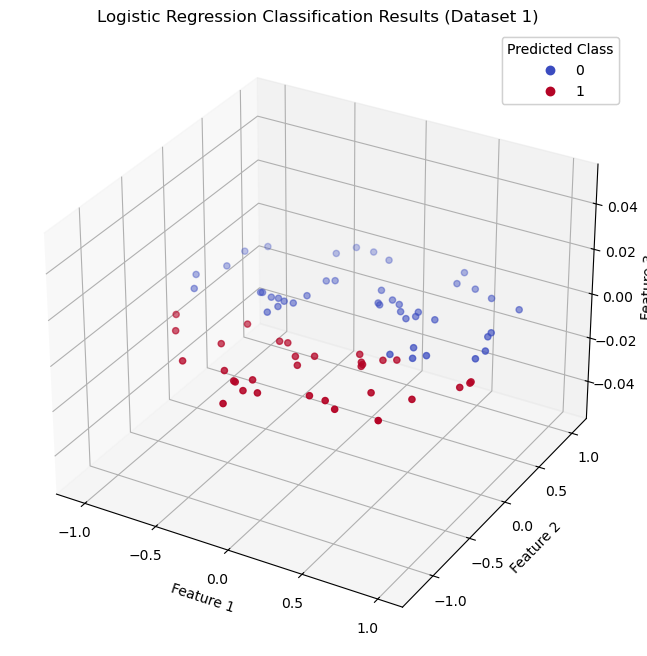

In [90]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(X_test2[:,0], X_test2[:,1],
                     c=y2_test_pred.flatten(),
                     cmap="coolwarm")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("Logistic Regression Classification Results (Dataset 1)")

legend1 = ax.legend(*scatter.legend_elements(), title="Predicted Class")
ax.add_artist(legend1)

plt.show()

#### Learnings of Task 2:  
   - Logistic regression is effective only for **linearly separable datasets**.  
   - Non-linear datasets require **more complex models** (e.g., kernel methods, decision trees, neural networks).  
   - Monitoring **epoch-wise loss** is crucial to detect convergence and overfitting.  
   - **Learning rate tuning** affects convergence speed and stability.

## Task 3: Implement and test a shallow Neural Network


We implemented a **Shallow Neural Network** with one hidden layer using **forward and backward propagation**.

## Initialization
* Weights initialized randomly × 0.01, biases = 0.
* Hidden layer: `n_hidden` neurons, output layer: 1 neuron.

## Forward Propagation
* Hidden layer: `Z1 = W1·X + b1`, `A1 = sigmoid(Z1)`
* Output layer: `Z2 = W2·A1 + b2`, `A2 = sigmoid(Z2)`
* `A2` gives predicted probabilities.

## Backward Propagation
* Output layer gradients: `dZ2 = A2 - Y`, `dW2 = dZ2·A1^T`, `db2 = dZ2`
* Hidden layer gradients: `dZ1 = W2^T·dZ2 * sigmoid_derivative(A1)`, `dW1 = dZ1·X^T`, `db1 = dZ1`
* Update weights and biases with learning rate.

## Training
* Loop over epochs and samples performing forward + backward pass.
* Track loss and stop when **convergence** is reached.

## Observations
* Increasing `n_hidden` improved learning on non-linear data.
* SNN performed very well on linearly separable data and required more hidden neurons for non-linear data.


In [29]:
#defining sigmoid derivative function for backward propogation
def sigmoid_derivative(a):
    """
    Implementation of sigmoid derivative function for backpropagation
    
    Inputs:
    a = activated output from sigmoid function
    
    Outputs:
    Returns the gradient of sigmoid, used to update weights during backward propagation
    """
    return a * (1 - a)

In [30]:
#initialising weights and bias 
def initialize_network(n_inputs, n_hidden):
    """
    Implementation of parameter initialization for a 1-hidden-layer neural network
    
    Inputs:
    n_inputs = number of input features
    n_hidden = number of neurons in hidden layer
    
    Outputs:
    W1, b1: for hidden layer
    W2, b2: for output layer
    """
    np.random.seed(42)
    params = {}
    params['W1'] = np.random.randn(n_hidden, n_inputs) * 0.01    #hidden layer weight
    params['b1'] = np.zeros((n_hidden, 1))                       #hidden layer bias
    params['W2'] = np.random.randn(1, n_hidden) * 0.01           #output layer weight
    params['b2'] = np.zeros((1, 1))                              #output layer bias
    return params

In [31]:
def forward(x, params):
    """
    Implementation of forward propagation for a 1-hidden-layer neural network
    
    Inputs:
    x = input data (training)
    params = W1, b1, W2, b2
    
    Outputs:
    a2 = final output
    cache = intermediate values needed for backpropagation
    """
    z1 = np.dot(params['W1'], x) + params['b1']             
    a1 = sigmoid(z1)
    z2 = np.dot(params['W2'], a1) + params['b2']
    a2 = sigmoid(z2)
    cache = {'x': x, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return a2, cache

In [32]:
#Backward propogation & updating weights & bias
def backward(y, params, cache, learning_rate):
    """
    Implementation of backward propagation and parameter update for a 1-hidden-layer neural network
    
    Inputs:
    y = true labels
    params = W1, b1, W2, b2
    cache = intermediate values needed for backpropagation
    learning_rate =  step size used to update network parameters
    
    Outputs:
    params = updated parameters after applying gradient descent
    """
    x = cache['x']
    a1 = cache['a1']
    a2 = cache['a2']

    dz2 = a2 - y
    dW2 = np.dot(dz2, a1.T)
    db2 = dz2

    dz1 = np.dot(params['W2'].T, dz2) * sigmoid_derivative(a1)
    dW1 = np.dot(dz1, x.T)
    db1 = dz1

    params['W2'] -= learning_rate * dW2
    params['b2'] -= learning_rate * db2
    params['W1'] -= learning_rate * dW1
    params['b1'] -= learning_rate * db1

    return params

In [33]:
def train_network(X, Y, n_hidden=2, learning_rate=0.001, epochs=1000, tolerance=1e-6):
    """
    Implementation of training procedure using Shallow Neural networ for a 1-hidden-layer
    
    Inputs:
    X = input data (training)
    Y = true labels 
    n_hidden = number of nodes in hidden layer
    learning_rate = step size for updates
    epochs = maximum number of training iterations
    tolerance = threshold for convergence 
    
    Outputs:
    params = W1, b1, W2, b2
    losses = list of average training loss per epoch
    converged_epoch = epoch number where convergence occurred
    """
    n_inputs = X.shape[0]
    params = initialize_network(n_inputs, n_hidden)
    m = X.shape[1]
    losses = []

    prev_loss = float('inf')
    converged_epoch = None

    for epoch in range(epochs):
        epoch_loss = 0

        for i in range(m):
            x = X[:, i:i+1]
            y = Y[:, i:i+1]

            a2, cache = forward(x, params)                         #foraward pass
            params = backward(y, params, cache, learning_rate)    #backward pass

            #computing loss
            epsilon = 1e-8
            a2_clipped = np.clip(a2, epsilon, 1 - epsilon)
            loss_value = - (y * np.log(a2_clipped) + (1 - y) * np.log(1 - a2_clipped))
            epoch_loss += loss_value.item()

        loss_avg = epoch_loss / m
        losses.append(loss_avg)

        # if (epoch + 1) % 100 == 0:
        #     print(f"Epoch {epoch+1}, Loss: {loss_avg:.6f}")

        # Convergence Check
        if abs(prev_loss - loss_avg) < tolerance:
            converged_epoch = epoch + 1
            print(f"\nConverged at epoch {converged_epoch} with Loss: {loss_avg:.6f}")
            break

        prev_loss = loss_avg

    return params, losses, converged_epoch


In [34]:
def predict(X, params):
    """
    Implementation of prediction function for a trained SNN
    
    Inputs:
    X = input data (test / Val)
    params = W1, b1, W2, b2
    
    Outputs:
    predictions 
    """
    m = X.shape[1]
    predictions = np.zeros((1, m))
    for i in range(m):
        x = X[:, i:i+1]
        a2, _ = forward(x, params)
        predictions[0, i] = 1 if a2 > 0.5 else 0
    return predictions

In [35]:

# Reshaping Features for dataset 1
X_blobs_train = X_train1.T  # shape: (n_features, n_samples)
Y_blobs_train = Y_train1.reshape(1,-1)  #(1. n_samples) format
X_blobs_test = X_test1.T 
Y_blobs_test = Y_test1.reshape(1,-1)
X_blobs_val = X_val1.T 
Y_blobs_val = Y_val1.reshape(1,-1)


Running for 4 hidden nodes

Converged at epoch 2164 with Loss: 0.008853
Test Accuracy for 4 hidden nodes: 1.00%
Test Precision for 4 hidden nodes: 1.00%
Test Recall for 4 hidden nodes: 1.00%
Test F1-score for 4 hidden nodes: 1.00%
Validate Accuracy for 4 hidden nodes: 0.99%
Validate Precision for 4 hidden nodes: 0.98%
Validate Recall for 4 hidden nodes: 1.00%
Validate F1-score for 4 hidden nodes: 0.99%


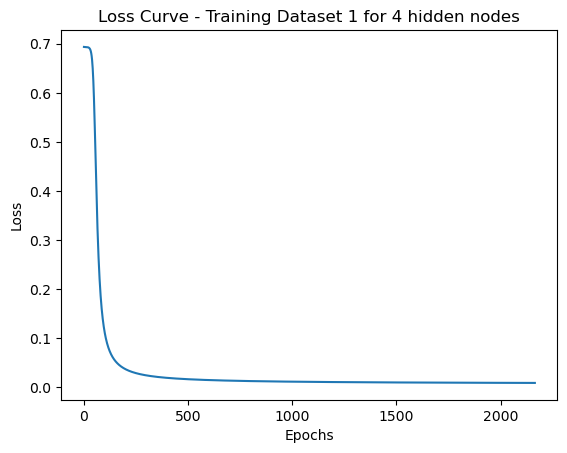

Running for 10 hidden nodes

Converged at epoch 1810 with Loss: 0.008735
Test Accuracy for 10 hidden nodes: 1.00%
Test Precision for 10 hidden nodes: 1.00%
Test Recall for 10 hidden nodes: 1.00%
Test F1-score for 10 hidden nodes: 1.00%
Validate Accuracy for 10 hidden nodes: 0.99%
Validate Precision for 10 hidden nodes: 0.98%
Validate Recall for 10 hidden nodes: 1.00%
Validate F1-score for 10 hidden nodes: 0.99%


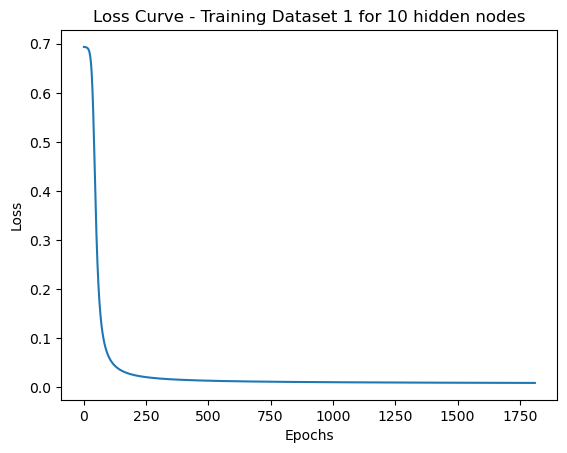

Running for 17 hidden nodes

Converged at epoch 1740 with Loss: 0.008773
Test Accuracy for 17 hidden nodes: 1.00%
Test Precision for 17 hidden nodes: 1.00%
Test Recall for 17 hidden nodes: 1.00%
Test F1-score for 17 hidden nodes: 1.00%
Validate Accuracy for 17 hidden nodes: 0.99%
Validate Precision for 17 hidden nodes: 0.98%
Validate Recall for 17 hidden nodes: 1.00%
Validate F1-score for 17 hidden nodes: 0.99%


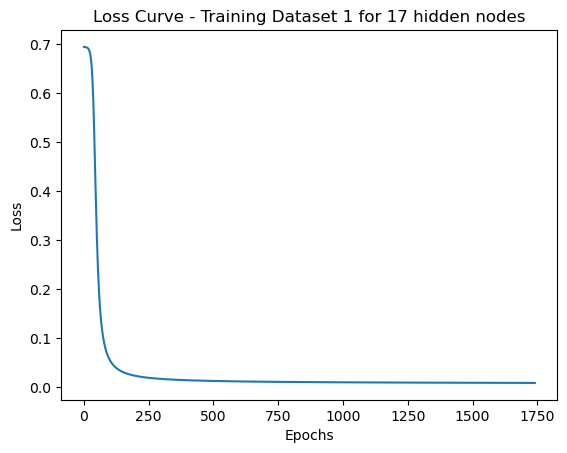

Running for 26 hidden nodes

Converged at epoch 1687 with Loss: 0.008816
Test Accuracy for 26 hidden nodes: 1.00%
Test Precision for 26 hidden nodes: 1.00%
Test Recall for 26 hidden nodes: 1.00%
Test F1-score for 26 hidden nodes: 1.00%
Validate Accuracy for 26 hidden nodes: 0.99%
Validate Precision for 26 hidden nodes: 0.98%
Validate Recall for 26 hidden nodes: 1.00%
Validate F1-score for 26 hidden nodes: 0.99%


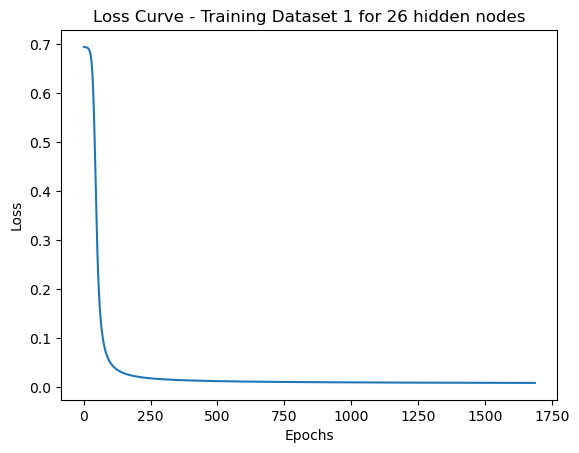

In [36]:
for n_hidden in [4,10,17,26]:   #trying with different number of nodes 
    print(f"Running for {n_hidden} hidden nodes")
    params_blobs_train, losses_blobs_train, converged_epoch_train = train_network(X_blobs_train, Y_blobs_train, n_hidden=n_hidden, learning_rate=0.001, epochs=50000)
    y_test_pred1 = predict(X_blobs_test, params_blobs_train)
    SNN_test_accuracy1, SNN_test_precision1, SNN_test_recall1, SNN_test_f1_1 = evaluate(Y_blobs_test, y_test_pred1)
    print(f"Test Accuracy for {n_hidden} hidden nodes: {SNN_test_accuracy1:.2f}%")
    print(f"Test Precision for {n_hidden} hidden nodes: {SNN_test_precision1:.2f}%")
    print(f"Test Recall for {n_hidden} hidden nodes: {SNN_test_recall1:.2f}%")
    print(f"Test F1-score for {n_hidden} hidden nodes: {SNN_test_f1_1:.2f}%")
    

    y_val_pred1 = predict(X_blobs_val, params_blobs_train)
    SNN_val_accuracy1, SNN_val_precision1, SNN_val_recall1, SNN_val_f1_1 = evaluate(Y_blobs_val, y_val_pred1)
    print(f"Validate Accuracy for {n_hidden} hidden nodes: {SNN_val_accuracy1:.2f}%")
    print(f"Validate Precision for {n_hidden} hidden nodes: {SNN_val_precision1:.2f}%")
    print(f"Validate Recall for {n_hidden} hidden nodes: {SNN_val_recall1:.2f}%")
    print(f"Validate F1-score for {n_hidden} hidden nodes: {SNN_val_f1_1:.2f}%")

    #plotting losses
    plt.plot(range(1, len(losses_blobs_train) + 1), losses_blobs_train)
    plt.title(f"Loss Curve - Training Dataset 1 for {n_hidden} hidden nodes")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


Running for 4 hidden nodes

Converged at epoch 4397 with Loss: 0.003855


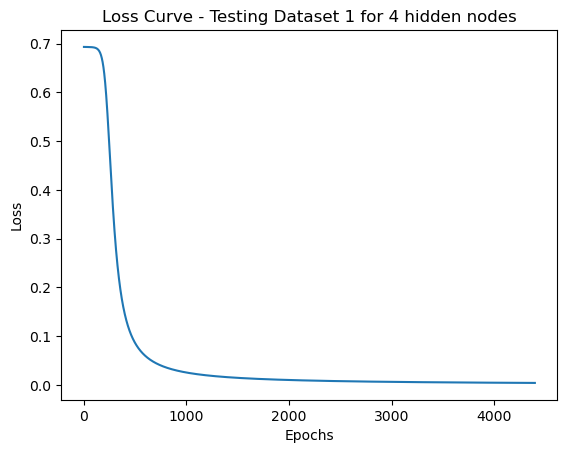


Converged at epoch 7099 with Loss: 0.008491


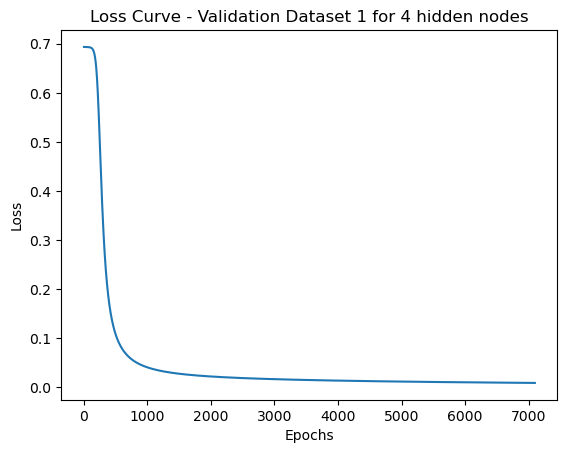

Running for 10 hidden nodes

Converged at epoch 3511 with Loss: 0.002964


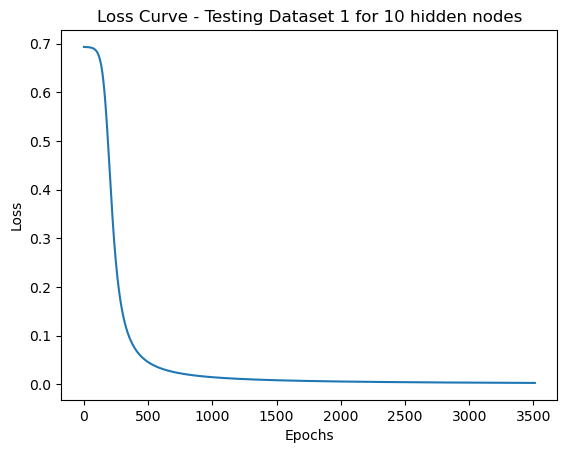


Converged at epoch 6310 with Loss: 0.009235


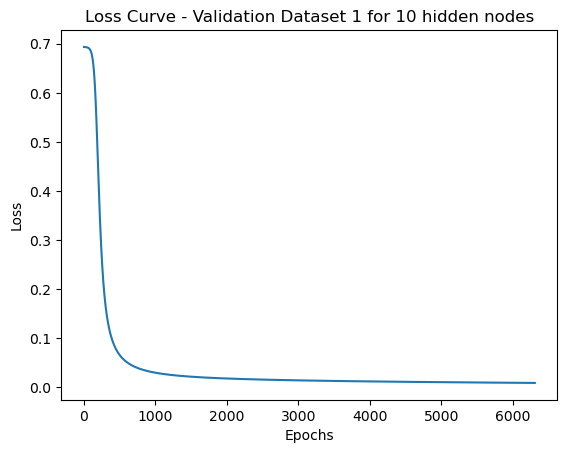

Running for 17 hidden nodes

Converged at epoch 3357 with Loss: 0.002837


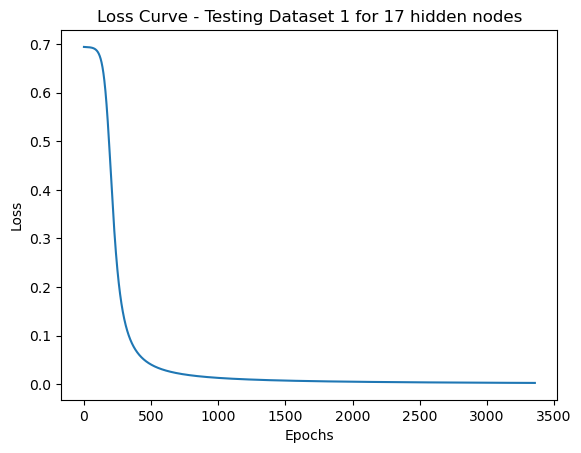


Converged at epoch 6181 with Loss: 0.009563


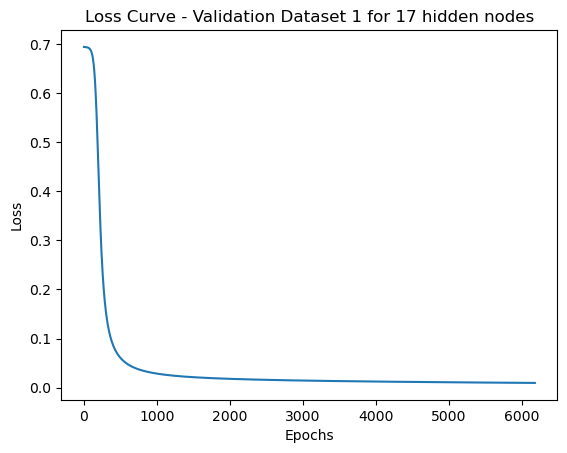

Running for 26 hidden nodes

Converged at epoch 3223 with Loss: 0.002746


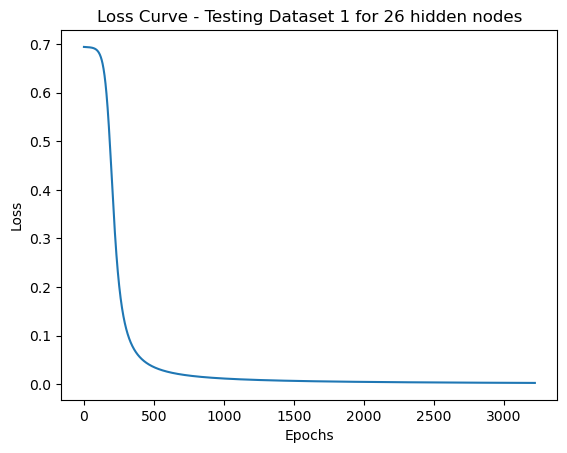


Converged at epoch 6130 with Loss: 0.009816


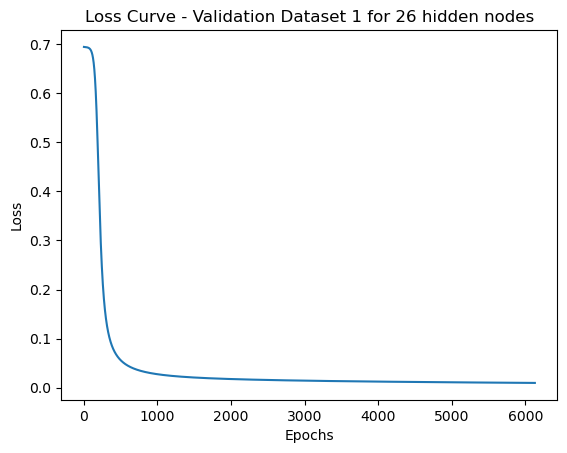

In [37]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_blobs_test, losses_blobs_test, converged_epoch_test = train_network(X_blobs_test, Y_blobs_test, n_hidden=n_hidden, learning_rate=0.001, epochs=50000)
    y_test_pred1 = predict(X_blobs_test, params_blobs_test)
    
    plt.plot(range(1, len(losses_blobs_test) + 1), losses_blobs_test)
    plt.title(f"Loss Curve - Testing Dataset 1 for {n_hidden} hidden nodes")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    params_blobs_val, losses_blobs_val, converged_epoch_val = train_network(
    X_blobs_val, 
    Y_blobs_val, 
    n_hidden=n_hidden, 
    learning_rate=0.001, 
    epochs=50000
    )

    #plotting losses
    plt.plot(range(1, len(losses_blobs_val) + 1), losses_blobs_val)
    plt.title(f"Loss Curve - Validation Dataset 1 for {n_hidden} hidden nodes")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


### Implementing SNN on Dataset 2 (Non-linearly separable data)

In [38]:
# Reshaping Features for dataset 2
X_circles_train = X_train2.T
Y_circles_train = Y_train2.reshape(1,-1)
X_circles_test = X_test2.T
Y_circles_test = Y_test2.reshape(1, -1)
X_circles_val = X_val2.T
Y_circles_val = Y_val2.reshape(1, -1)

Running for 4 hidden nodes

Converged at epoch 5 with Loss: 0.695515
Test Accuracy for 4 hidden nodes: 0.49%
Test Precision for 4 hidden nodes: 0.49%
Test Recall for 4 hidden nodes: 1.00%
Test F1-score for 4 hidden nodes: 0.66%
Validate Accuracy for 4 hidden nodes: 0.51%
Validate Precision for 4 hidden nodes: 0.51%
Validate Recall for 4 hidden nodes: 1.00%
Validate F1-score for 4 hidden nodes: 0.67%


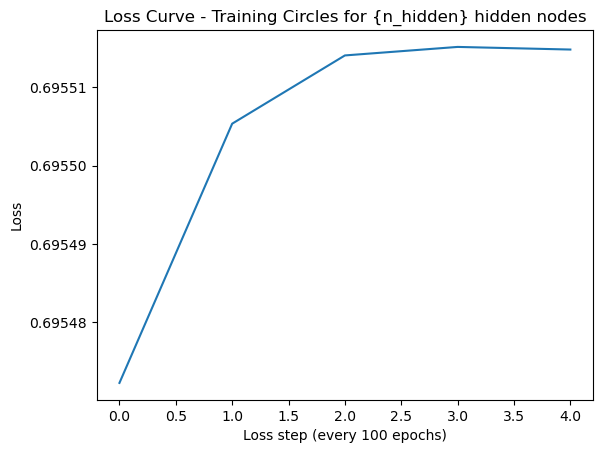

Running for 10 hidden nodes

Converged at epoch 5982 with Loss: 0.003714
Test Accuracy for 10 hidden nodes: 0.99%
Test Precision for 10 hidden nodes: 0.97%
Test Recall for 10 hidden nodes: 1.00%
Test F1-score for 10 hidden nodes: 0.99%
Validate Accuracy for 10 hidden nodes: 1.00%
Validate Precision for 10 hidden nodes: 1.00%
Validate Recall for 10 hidden nodes: 1.00%
Validate F1-score for 10 hidden nodes: 1.00%


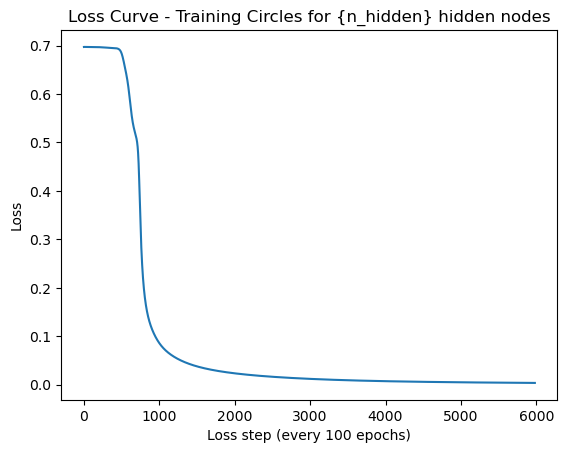

Running for 17 hidden nodes

Converged at epoch 4590 with Loss: 0.003907
Test Accuracy for 17 hidden nodes: 0.99%
Test Precision for 17 hidden nodes: 0.97%
Test Recall for 17 hidden nodes: 1.00%
Test F1-score for 17 hidden nodes: 0.99%
Validate Accuracy for 17 hidden nodes: 1.00%
Validate Precision for 17 hidden nodes: 1.00%
Validate Recall for 17 hidden nodes: 1.00%
Validate F1-score for 17 hidden nodes: 1.00%


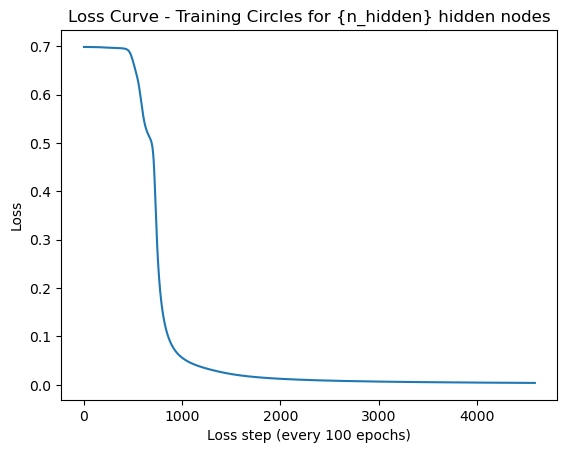

Running for 26 hidden nodes

Converged at epoch 6285 with Loss: 0.004425
Test Accuracy for 26 hidden nodes: 0.99%
Test Precision for 26 hidden nodes: 0.97%
Test Recall for 26 hidden nodes: 1.00%
Test F1-score for 26 hidden nodes: 0.99%
Validate Accuracy for 26 hidden nodes: 1.00%
Validate Precision for 26 hidden nodes: 1.00%
Validate Recall for 26 hidden nodes: 1.00%
Validate F1-score for 26 hidden nodes: 1.00%


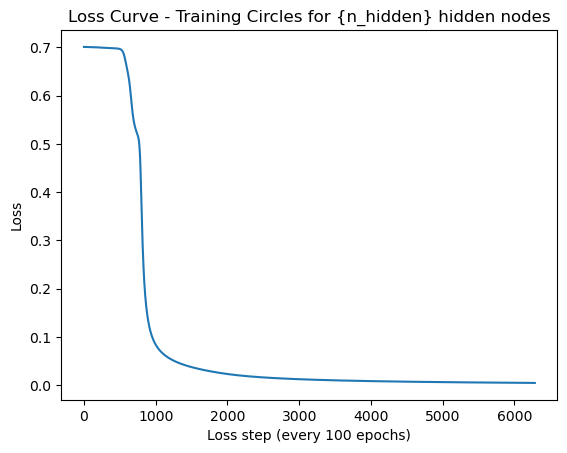

In [39]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_circles_train, losses_circles_train, converged_epoch_train = train_network(X_circles_train, Y_circles_train, n_hidden=n_hidden, learning_rate=0.01, epochs=20000)
    y_test_pred2 = predict(X_circles_test, params_circles_train)
    SNN_test_accuracy2, SNN_test_precision2, SNN_test_recall2, SNN_test_f1_2 = evaluate(Y_circles_test, y_test_pred2)
    print(f"Test Accuracy for {n_hidden} hidden nodes: {SNN_test_accuracy2:.2f}%")
    print(f"Test Precision for {n_hidden} hidden nodes: {SNN_test_precision2:.2f}%")
    print(f"Test Recall for {n_hidden} hidden nodes: {SNN_test_recall2:.2f}%")
    print(f"Test F1-score for {n_hidden} hidden nodes: {SNN_test_f1_2:.2f}%")

    y_val_pred2 = predict(X_circles_val, params_circles_train)
    SNN_val_accuracy2, SNN_val_precision2, SNN_val_recall2, SNN_val_f1_2 = evaluate(Y_circles_val, y_val_pred2)
    print(f"Validate Accuracy for {n_hidden} hidden nodes: {SNN_val_accuracy2:.2f}%")
    print(f"Validate Precision for {n_hidden} hidden nodes: {SNN_val_precision2:.2f}%")
    print(f"Validate Recall for {n_hidden} hidden nodes: {SNN_val_recall2:.2f}%")
    print(f"Validate F1-score for {n_hidden} hidden nodes: {SNN_val_f1_2:.2f}%")

    plt.plot(losses_circles_train)
    plt.title("Loss Curve - Training Circles for {n_hidden} hidden nodes")
    plt.xlabel("Loss step (every 100 epochs)")
    plt.ylabel("Loss")
    plt.show()

    

## Task 4: Tackle a challenging task

- Worked on EMNIST handwritten letters dataset (28×28 images, 26 classes).
- Converted it into a binary classification problem by selecting two letters and flattening images into 784 features.
- Trained a shallow neural network with different hidden nodes (3, 4, 6) and evaluated performance.


In [41]:
# data = np.load(r"C:\Users\anush\Downloads\emnist_letters_85800.npz")
data = np.load(r"/Users/aakankshadeshpande/Documents/Assignments_Sem2/emnist_letters_85800.npz")
x_data = data["x"]
y_data = data["y"]

In [42]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


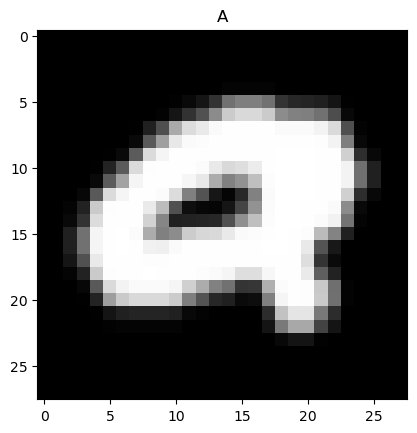

In [43]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))  
plt.show()

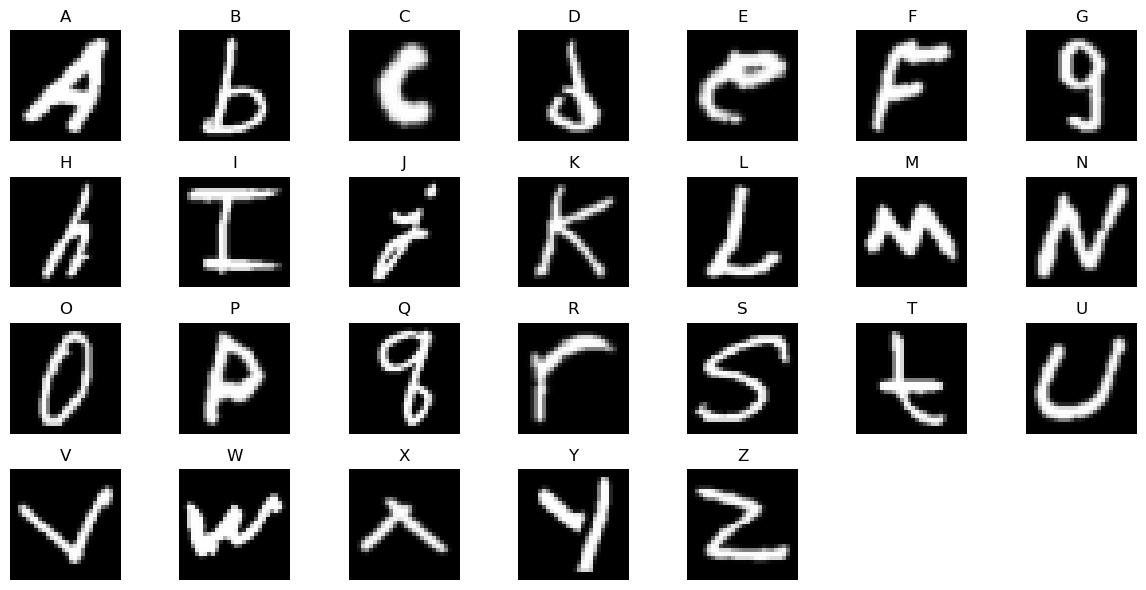

In [44]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    # Find first index of this class
    idx = np.where(y_data == cls)[0][n]
    
    plt.subplot(4, 7, i + 1)
    plt.imshow(x_data[idx].squeeze(), cmap="gray")
    plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 1   # example
c2 = 18  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [46]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

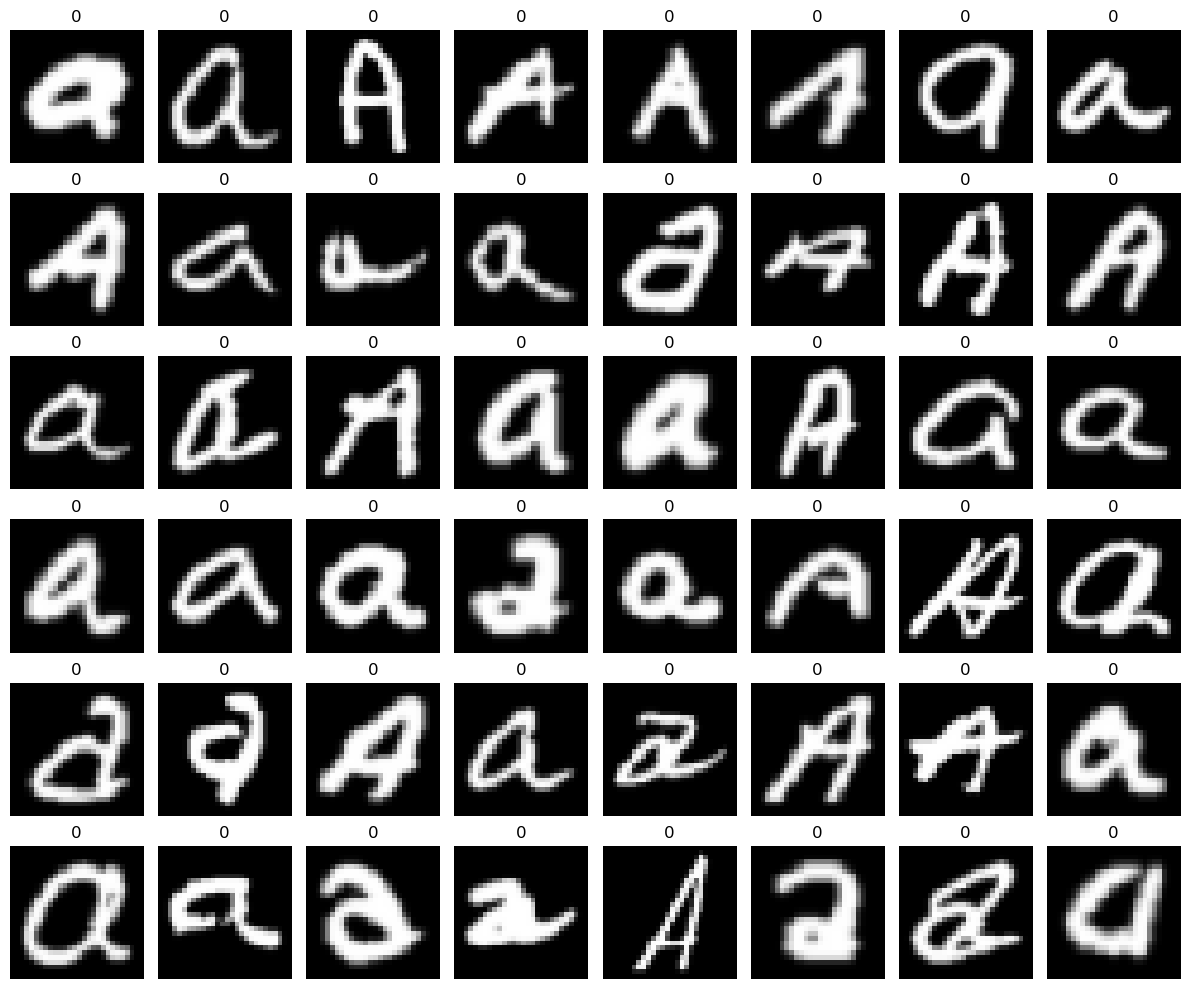

In [47]:
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

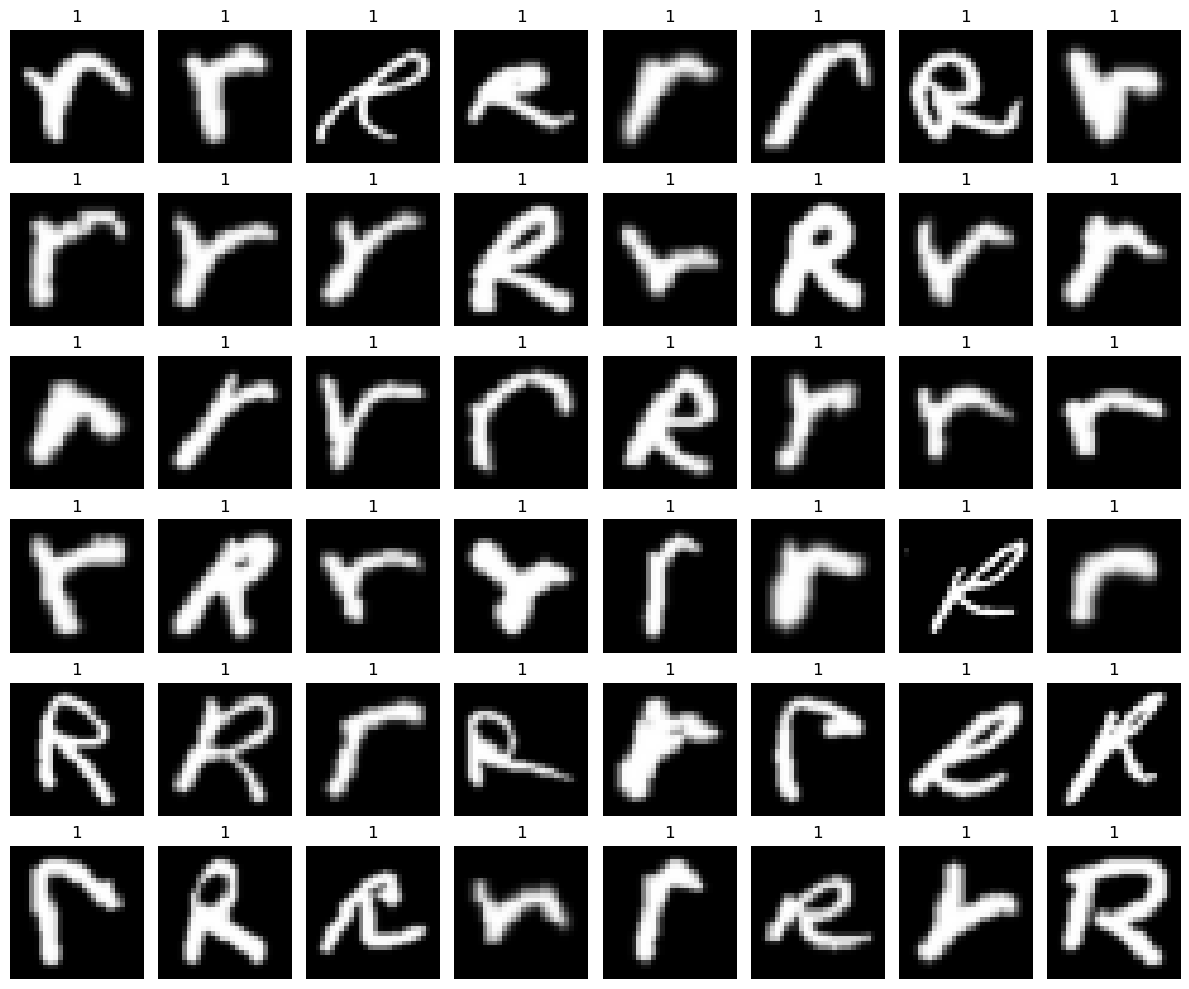

In [48]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

In [49]:
#Flattening image
x_binary = x_binary.reshape(x_binary.shape[0], -1).T  #(features x samples) format --> changing this format for feasible matrix multiplication
y_binary = y_binary.reshape(1, -1)                    #(1 x samples) format
y_binary_1d = y_binary.flatten()                      

In [50]:
#implementing train test val split
X_temp, X_test, Y_temp, Y_test = train_test_split(
    x_binary.T, y_binary_1d, test_size=0.2, random_state=42, stratify=y_binary_1d
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, stratify=Y_temp
) 


In [51]:
X_train, X_val, X_test = X_train.T, X_val.T, X_test.T   #getting back to original data format (samples x features)

In [52]:
Y_train = Y_train.reshape(1, -1)
Y_val   = Y_val.reshape(1, -1)
Y_test  = Y_test.reshape(1, -1)

In [53]:
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")

X_train shape: (784, 3960), Y_train shape: (1, 3960)


Running for 3 hidden nodes

Converged at epoch 122 with Loss: 0.031735


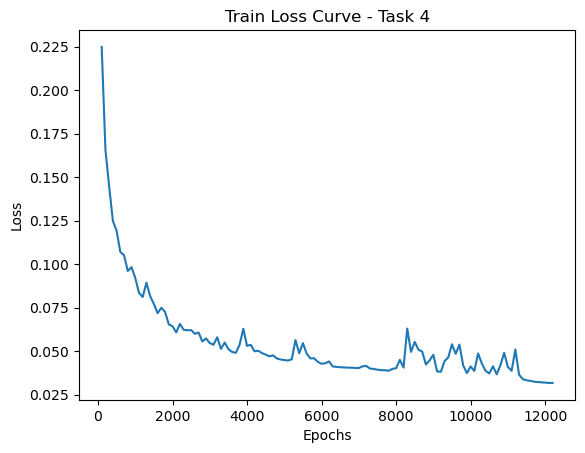

Train Accuracy: 99.12%
Train Precision: 99.74%
Train Recall: 98.48%
Train F1-score: 99.11%
Test Accuracy: 95.91%
Test Precision: 95.36%
Test Recall: 96.52%
Test F1-score: 95.93%
Validate Accuracy: 95.91%
Validate Precision: 95.50%
Validate Recall: 96.36%
Validate F1-score: 95.93%
Running for 4 hidden nodes

Converged at epoch 674 with Loss: 0.016069


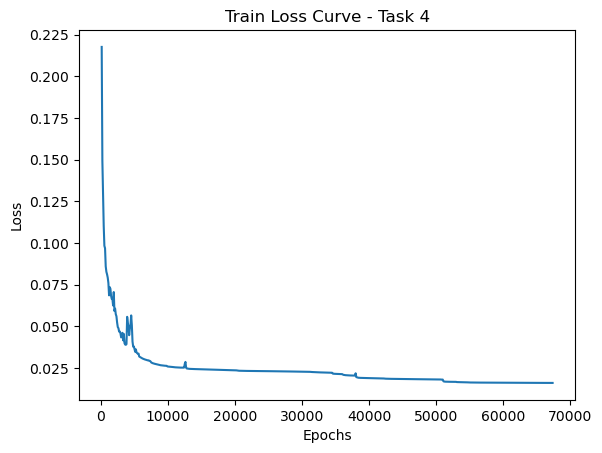

Train Accuracy: 99.55%
Train Precision: 99.45%
Train Recall: 99.65%
Train F1-score: 99.55%
Test Accuracy: 96.06%
Test Precision: 95.78%
Test Recall: 96.36%
Test F1-score: 96.07%
Validate Accuracy: 95.68%
Validate Precision: 95.75%
Validate Recall: 95.61%
Validate F1-score: 95.68%
Running for 6 hidden nodes

Converged at epoch 536 with Loss: 0.010340


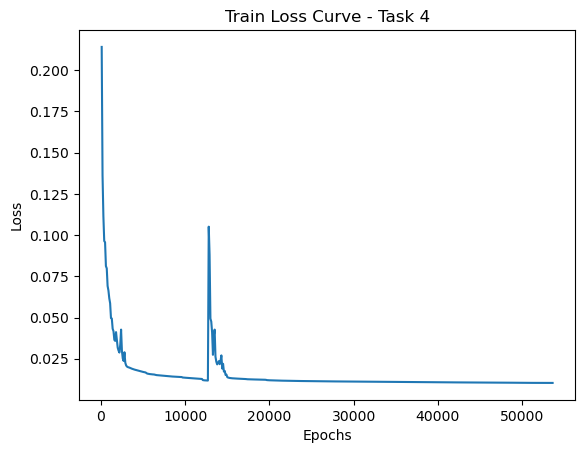

Train Accuracy: 99.80%
Train Precision: 99.95%
Train Recall: 99.65%
Train F1-score: 99.80%
Test Accuracy: 96.97%
Test Precision: 96.97%
Test Recall: 96.97%
Test F1-score: 96.97%
Validate Accuracy: 96.06%
Validate Precision: 96.34%
Validate Recall: 95.76%
Validate F1-score: 96.05%


In [54]:
for n_hidden in [3, 4, 6]:
    print(f"Running for {n_hidden} hidden nodes")
    params_letters, losses_letters, convergence_epoch = train_network(
        X_train, Y_train, n_hidden=n_hidden, learning_rate=0.1, epochs=2000
    )
    
    plt.plot(np.arange(1, len(losses_letters)+1) * 100, losses_letters)
    plt.title("Train Loss Curve - Task 4")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    pred_train = predict(X_train, params_letters)
    pred_val = predict(X_val, params_letters)
    pred_test = predict(X_test, params_letters)

    SNN_train_accuracy, SNN_train_precision, SNN_train_recall, SNN_train_f1 = evaluate(Y_train, pred_train)
    SNN_test_accuracy, SNN_test_precision, SNN_test_recall, SNN_test_f1 = evaluate(Y_test, pred_test)
    SNN_val_accuracy, SNN_val_precision, SNN_val_recall, SNN_val_f1 = evaluate(Y_val, pred_val)

    print(f"Train Accuracy: {SNN_train_accuracy*100:.2f}%")
    print(f"Train Precision: {SNN_train_precision*100:.2f}%")
    print(f"Train Recall: {SNN_train_recall*100:.2f}%")
    print(f"Train F1-score: {SNN_train_f1*100:.2f}%")
    
    print(f"Test Accuracy: {SNN_test_accuracy*100:.2f}%")
    print(f"Test Precision: {SNN_test_precision*100:.2f}%")
    print(f"Test Recall: {SNN_test_recall*100:.2f}%")
    print(f"Test F1-score: {SNN_test_f1*100:.2f}%")
    
    print(f"Validate Accuracy: {SNN_val_accuracy*100:.2f}%")
    print(f"Validate Precision: {SNN_val_precision*100:.2f}%")
    print(f"Validate Recall: {SNN_val_recall*100:.2f}%")
    print(f"Validate F1-score: {SNN_val_f1*100:.2f}%")

#### Learnings of Task 4:

- Model achieved very high training accuracy and strong test accuracy.
- Increasing hidden nodes improved training performance slightly.
- Small gap between train and test accuracy indicates good generalization with mild overfitting.
- Neural networks perform well on image data even with a simple architecture.

## Task 5: Deep Learning Enhancements

- Implemented a fully connected Deep Neural Network with multiple hidden layers.
- Added L2 regularization and Early Stopping to reduce overfitting.
- Compared shallow vs deep architectures and evaluated Train, Validation, and Test performance.

In [55]:
def initialize_parameters(layer_dimensions):
    """
    Implementation of parameter initialization for a deep neural network
    
    Inputs:
    layer_dimensions = the number of nodes in each layer
    
    Outputs:
    parameters 
    """
    np.random.seed(42)
    parameters = {}

    for l in range(1, len(layer_dimensions)):
        scale = np.sqrt(1 / layer_dimensions[l-1])

        parameters[f"W{l}"] = np.random.randn(
            layer_dimensions[l], layer_dimensions[l-1]
        ) * scale

        parameters[f"b{l}"] = np.zeros((layer_dimensions[l], 1))

    return parameters

def forward_propagation(X, parameters, training=True):
    """
    Implementation of forward propagation for a deep neural network.
    
    Inputs:
    X = input data (training)
    parameters 
    training = boolean flag to control use of L2 regularisation
    
    Outputs:
    activation_layer_output = final output of the network 
    cache = intermediate values needed for backpropagation
    """
    cache = {"A0": X}
    L = len(parameters)//2
   
    for l in range(1, L):

        output = parameters[f"W{l}"] @ cache[f"A{l-1}"] + parameters[f"b{l}"]
        activation = sigmoid(output)

        cache[f"Z{l}"] = output
        cache[f"A{l}"] = activation

    output_layer = parameters[f"W{L}"] @ cache[f"A{L-1}"] + parameters[f"b{L}"]
    activation_layer_output = sigmoid(output_layer)

    cache[f"output{L}"] = output_layer
    cache[f"activation{L}"] = activation_layer_output
   
    return activation_layer_output, cache

def compute_loss(activation_layer_output, Y, parameters, lambda_l2=0.01):
    """
    Implementation of binary cross-entropy loss with optional L2 regularization
    for a deep neural network.
    
    Inputs:
    activation_layer_output = predicted output from the network
    Y = true labels
    parameters 
    lambda_l2 = regularization hyperparameter
    
    Outputs:
    total_loss 
    """
    m = Y.shape[1]
    epsilon = 1e-15
   
    activation_layer_output = np.clip(activation_layer_output, epsilon, 1-epsilon)

    cross_entropy = -np.mean(Y*np.log(activation_layer_output) + (1-Y)*np.log(1-activation_layer_output))

    # L2 term
    l2 = 0
    for l in range(1, len(parameters)//2 + 1):
        l2 += np.sum(np.square(parameters[f"W{l}"]))

    l2_term = (lambda_l2/(2*m)) * l2

    return cross_entropy + l2_term



In [56]:
def backward_propagation(parameters, cache, X, Y, lambda_l2=0.01):
    """
    Implementation of backward propagation for a deep neural network
    
    Inputs:
    parameters 
    cache = intermediate values from forward propagation
    X = input data 
    Y = true labels 
    lambda_l2 = L2 regularization hyperparameter
    
    Outputs:
    gradients 
    """
    gradients = {}
    L = len(parameters)//2
    m = X.shape[1]

    activation_layer_output = cache[f"activation{L}"]
    dZ = activation_layer_output - Y

    for l in reversed(range(1, L+1)):

        gradients[f"dW{l}"] = (1/m)*(dZ @ cache[f"A{l-1}"].T) + (lambda_l2/m)*parameters[f"W{l}"]
        gradients[f"db{l}"] = (1/m)*np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dA_prev = parameters[f"W{l}"].T @ dZ
            A_prev = cache[f"A{l-1}"]
            dZ = dA_prev * sigmoid_derivative(A_prev)

    return gradients

In [57]:
def update_parameters(parameters, gradients, lr):
    """
    Implementation of gradient descent parameter update for a deep neural network.
    
    Inputs:
    parameters 
    gradients 
    lr = learning rate used for the update
    
    Outputs:
    parameters = updated network parameters
    """
    for l in range(1, len(parameters)//2 + 1):
        parameters[f"W{l}"] -= lr * gradients[f"dW{l}"]
        parameters[f"b{l}"] -= lr * gradients[f"db{l}"]

    return parameters

In [58]:
def train_deep_network(X, Y, X_val, Y_val,
                       layers,
                       lr=0.01,
                       epochs=2000,
                       lambda_l2=0.01,
                       use_l2=True,      
                       tolerance=1e-8,
                       patience=5000):
    """
    Implementation of training for a deep neural network with optional L2 regularization and early stopping based on validation loss.
    
    Inputs:
    X = input training data
    Y = training labels
    X_val = validation input data
    Y_val = validation labels
    layers = number of node in each layer
    lr = learning rate for gradient descent
    epochs = maximum number of training iterations
    lambda_l2 = L2 regularization hyperparameter
    use_l2 = boolean flag to enable/disable L2 regularization
    tolerance = threshold to reset early stopping counter
    patience = number of epochs to wait without improvement before early stopping
    
    Outputs:
    parameters
    losses 
    val_losses 
    """
    parameters = initialize_parameters(layers)
    losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0

    for i in range(epochs):

        activation_layer_output, cache = forward_propagation(X, parameters)
        loss = compute_loss(activation_layer_output, Y, parameters, lambda_l2 if use_l2 else 0)
        losses.append(loss)

        activation_val, _ = forward_propagation(X_val, parameters)
        val_loss = compute_loss(activation_val, Y_val, parameters, lambda_l2 if use_l2 else 0)
        val_losses.append(val_loss)

        gradients = backward_propagation(parameters, cache, X, Y, lambda_l2 if use_l2 else 0)
        parameters = update_parameters(parameters, gradients, lr)

        if val_loss < best_val_loss - tolerance:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter > patience:
            print(f"Early stopping at epoch {i}")
            break

        # if i % 200 == 0:
        #     print(f"Epoch {i} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}")

    return parameters, losses, val_losses


In [59]:
# With L2 regularization
params_l2, losses_l2, val_losses_l2 = train_deep_network(
    X_train, Y_train, X_val, Y_val, [784, 4, 1], lr=0.1, epochs=1000, lambda_l2=0.01, use_l2=True
)

# Without L2 regularization
params_no_l2, losses_no_l2, val_losses_no_l2 = train_deep_network(
    X_train, Y_train, X_val, Y_val, [784, 4, 1], lr=0.1, epochs=1000, lambda_l2=0.01, use_l2=False
)

In [60]:
def predict_deep(X, params):
    """
    Implementation of prediction function for a trained deep neural network.
    
    Inputs:
    X = input data (test/val)
    params (trained network parameters: W1,...,WL and b1,...,bL)
    
    Outputs:
    predictions 
    """
    # Forward pass
    activation_layer_output, _ = forward_propagation(X, params)
    # Convert probabilities to 0/1
    predictions = (activation_layer_output > 0.5).astype(int)
    return predictions



Training network with layers: [784, 4, 1]


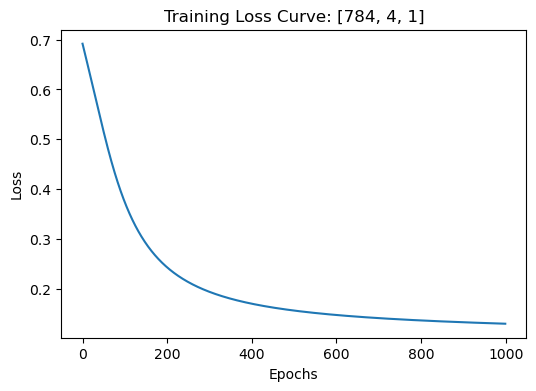

Train Accuracy: 95.76%
Train Precision: 96.60%
Train Recall: 94.85%
Train F1-score: 95.72%


Test Accuracy: 94.39%
Test Precision: 94.94%
Test Recall: 93.79%
Test F1-score: 94.36%


Validate Accuracy: 93.11%
Validate Precision: 93.17%
Validate Recall: 93.03%
Validate F1-score: 93.10%

Training network with layers: [784, 6, 3, 1]


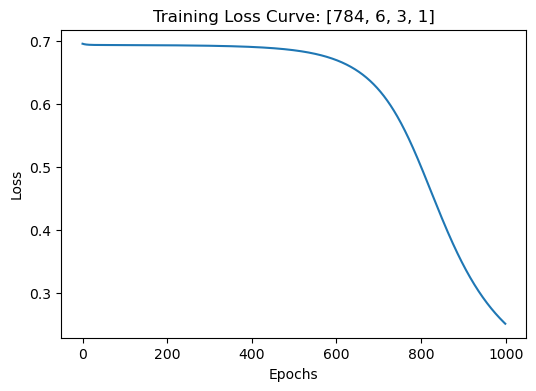

Train Accuracy: 93.61%
Train Precision: 96.25%
Train Recall: 90.76%
Train F1-score: 93.42%


Test Accuracy: 92.80%
Test Precision: 94.91%
Test Recall: 90.45%
Test F1-score: 92.63%


Validate Accuracy: 91.89%
Validate Precision: 93.54%
Validate Recall: 90.00%
Validate F1-score: 91.74%

Training network with layers: [784, 256, 128, 64, 1]


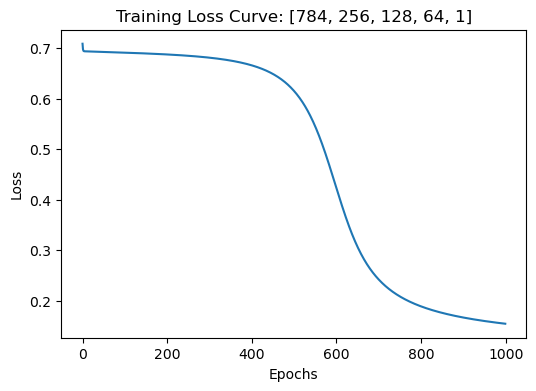

Train Accuracy: 94.39%
Train Precision: 95.83%
Train Recall: 92.83%
Train F1-score: 94.30%


Test Accuracy: 93.94%
Test Precision: 94.75%
Test Recall: 93.03%
Test F1-score: 93.88%


Validate Accuracy: 92.88%
Validate Precision: 93.54%
Validate Recall: 92.12%
Validate F1-score: 92.82%


In [61]:
layer_configs = [
    [X_train.shape[0], 4, 1],           
    [X_train.shape[0], 6, 3, 1],        
    [X_train.shape[0], 256, 128, 64, 1]
]


for layers in layer_configs:
    print(f"\nTraining network with layers: {layers}")
    parameters, losses, val_losses = train_deep_network(X_train, Y_train, X_val, Y_val, layers, lr=0.1, epochs=1000, lambda_l2=0.01)
    
    # Plot training loss
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.title(f"Training Loss Curve: {layers}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()
    
    # Predictions
    pred_train = predict_deep(X_train, parameters)
    pred_val   = predict_deep(X_val, parameters)
    pred_test  = predict_deep(X_test, parameters)

    DNN_train_accuracy, DNN_train_precision, DNN_train_recall, DNN_train_f1 = evaluate(Y_train, pred_train)
    DNN_test_accuracy, DNN_test_precision, DNN_test_recall, DNN_test_f1 = evaluate(Y_test, pred_test)
    DNN_val_accuracy, DNN_val_precision, DNN_val_recall, DNN_val_f1 = evaluate(Y_val, pred_val)

    print(f"Train Accuracy: {DNN_train_accuracy*100:.2f}%")
    print(f"Train Precision: {DNN_train_precision*100:.2f}%")
    print(f"Train Recall: {DNN_train_recall*100:.2f}%")
    print(f"Train F1-score: {DNN_train_f1*100:.2f}%")
    print("\n")
    print(f"Test Accuracy: {DNN_test_accuracy*100:.2f}%")
    print(f"Test Precision: {DNN_test_precision*100:.2f}%")
    print(f"Test Recall: {DNN_test_recall*100:.2f}%")
    print(f"Test F1-score: {DNN_test_f1*100:.2f}%")
    print("\n")
    print(f"Validate Accuracy: {DNN_val_accuracy*100:.2f}%")
    print(f"Validate Precision: {DNN_val_precision*100:.2f}%")
    print(f"Validate Recall: {DNN_val_recall*100:.2f}%")
    print(f"Validate F1-score: {DNN_val_f1*100:.2f}%")
    

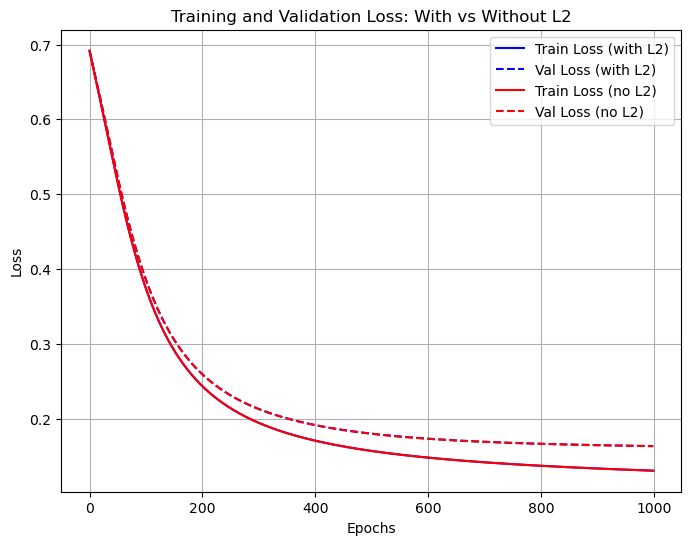

In [62]:
plt.figure(figsize=(8,6))

plt.plot(losses_l2, label="Train Loss (with L2)", color="blue")
plt.plot(val_losses_l2, label="Val Loss (with L2)", color="blue", linestyle="--")

plt.plot(losses_no_l2, label="Train Loss (no L2)", color="red")
plt.plot(val_losses_no_l2, label="Val Loss (no L2)", color="red", linestyle="--")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss: With vs Without L2")
plt.legend()
plt.grid(True)
plt.show()

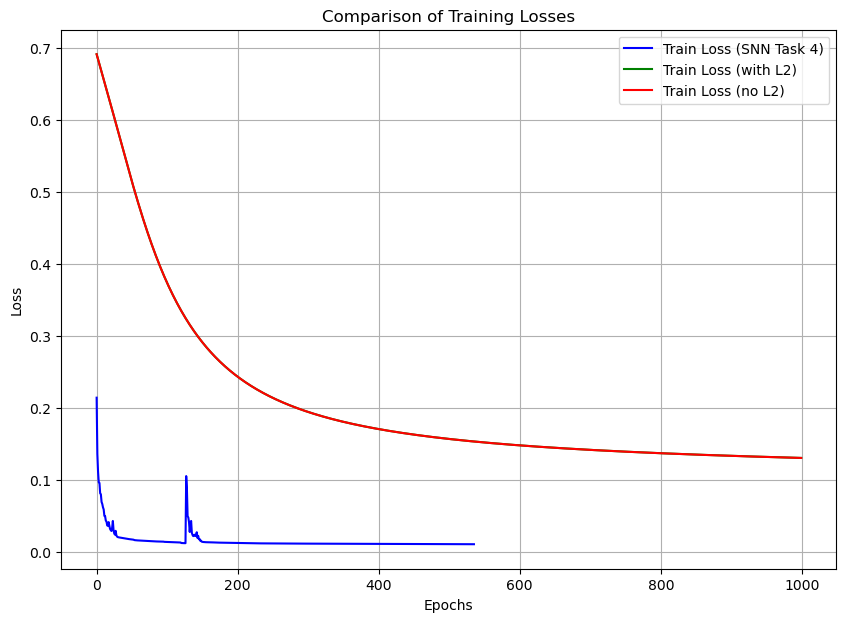

In [63]:
plt.figure(figsize=(10,7))

plt.plot(losses_letters, label="Train Loss (SNN Task 4)", color="blue")

plt.plot(losses_l2, label="Train Loss (with L2)", color="green")
plt.plot(losses_no_l2, label="Train Loss (no L2)", color="red")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparison of Training Losses")
plt.legend()
plt.grid(True)
plt.show()


In [64]:
shallow_train_acc = round(SNN_train_accuracy*100, 2)
shallow_val_acc   = round(SNN_val_accuracy*100, 2)
shallow_test_acc  = round(SNN_test_accuracy*100, 2)

deep_l2_train_acc = round(DNN_train_accuracy*100, 2)
deep_l2_val_acc   = round(DNN_val_accuracy*100, 2)
deep_l2_test_acc  = round(DNN_test_accuracy*100, 2)


deep_no_l2_train_acc = round(DNN_train_accuracy*100, 2) 
deep_no_l2_val_acc   = round(DNN_val_accuracy*100, 2)   
deep_no_l2_test_acc  = round(DNN_test_accuracy*100, 2)  


accuracy_table = pd.DataFrame({
    "Model": ["Shallow NN (SNN Task 4)", "Deep NN with L2", "Deep NN without L2"],
    "Train Accuracy (%)": [shallow_train_acc, deep_l2_train_acc, deep_no_l2_train_acc],
    "Validation Accuracy (%)": [shallow_val_acc, deep_l2_val_acc, deep_no_l2_val_acc],
    "Test Accuracy (%)": [shallow_test_acc, deep_l2_test_acc, deep_no_l2_test_acc]
})


accuracy_table


,Model,Train Accuracy (%),Validation Accuracy (%),Test Accuracy (%)
0,Shallow NN (SNN Task 4),99.80,96.06,96.97
1,Deep NN with L2,94.39,92.88,93.94
2,Deep NN without L2,94.39,92.88,93.94


#### Learnings of Task 5:

- The shallow network (Task 4) achieved the highest accuracy 
- Increasing depth did not significantly improve performance for this binary task.
- L2 regularization showed minimal difference, indicating limited overfitting because more complex models do not always guarantee better results.
- Simpler architectures generalize better for moderately complex datasets.